# 📘 Taller Evaluativo (20%) - Análisis de Portafolio
### Curso: Ingeniería Financiera / Programación  
### Herramienta: Google Colab  
---
### 🎯 Objetivo
Este taller busca que comprendas qué es un análisis de portafolio, cómo se calculan y analizan sus métricas (rentabilidad, riesgo y correlación), y cómo se interpreta el resultado para tomar decisiones de inversión.

👉 **Importante:** No basta con ejecutar el código. Debes **completar los espacios en blanco**, responder las **preguntas de investigación** y redactar un **análisis final**.

## 1. Importación de librerías
Primero, importa las librerías necesarias para trabajar con datos financieros.

In [57]:
# COMPLETAR: importa las librerías necesarias (yfinance, pandas, numpy, matplotlib, seaborn)
# Ejemplo: import yfinance as yf

# COMPLETAR AQUÍ

In [58]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Descarga de datos
Usa `yfinance` para descargar los precios de **Google (GOOG)**, **Amazon (AMZN)** y **Microsoft (MSFT)** durante los últimos 3 años. Utiliza la columna `Adj Close`.

🔎 **Pregunta:** ¿Por qué es más adecuado usar `Adj Close` que `Close` para un análisis financiero?

In [ ]:
acciones = ["GOOG", "AMZN", "MSFT"]

In [63]:
# COMPLETAR: descarga los precios de las acciones usando yf.download

datos = yf.download(tickers=acciones, start ="2022-01-01", end ="2025-09-18")["Close"]
datos.head() # Veo los primeros 5 datos

/tmp/ipython-input-3316423072.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(tickers=acciones, start ="2022-01-01", end ="2025-09-18")["Close"]
[*********************100%***********************]  3 of 3 completed


Ticker,AMZN,GOOG,MSFT
Date,,,
2022-01-03,170.404495,144.088470,324.504608
2022-01-04,167.522003,143.434952,318.940247
2022-01-05,164.356995,136.717896,306.696838
2022-01-06,163.253998,136.616089,304.273407
2022-01-07,162.554001,136.073318,304.428497


In [ ]:
datos.tail() # Veo los últimos 5 datos

Ticker,AMZN,GOOG,MSFT
Date,,,
2025-09-10,230.330002,239.559998,500.369995
2025-09-11,229.949997,240.779999,501.010010
2025-09-12,228.149994,241.380005,509.899994
2025-09-15,231.429993,251.759995,515.359985
2025-09-16,234.050003,251.419998,509.040009


## 3. Visualización de precios
Grafica en una misma figura la evolución de los precios de cierre ajustados de las tres acciones.

🔎 **Pregunta:** ¿Cuál de las tres acciones muestra mayor crecimiento en estos 3 años?

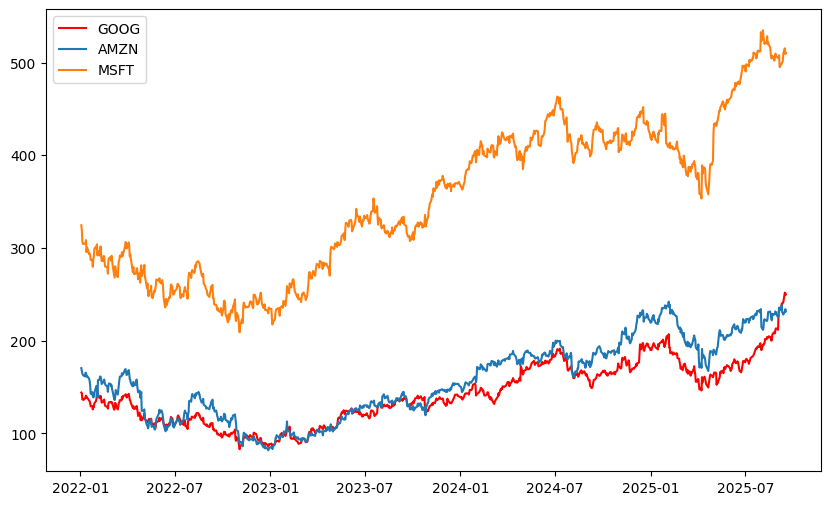

In [64]:
# COMPLETAR: grafica las tres series de precios en una sola gráfica

plt.figure(figsize=(10,6))
plt.plot(datos["GOOG"], label="GOOG",color="red")
plt.plot(datos["AMZN"], label="AMZN")
plt.plot(datos["MSFT"], label="MSFT")
plt.legend()
plt.show()

In [ ]:
import plotly.express as px

## 4. Rentabilidades
Calcula las **rentabilidades logarítmicas diarias** y grafícalas.

🔎 **Pregunta:** ¿Qué diferencias encuentras entre observar precios y observar rentabilidades?

In [69]:
print("Respuesta, los precios ayudan a observar la tendencia general y saber si la accion sube o baja, y las rentabilidades son cambios en el precio y representa la ganancia o perdida que genere")

Respuesta, los precios ayudan a observar la tendencia general y saber si la accion sube o baja, y las rentabilidades son cambios en el precio y representa la ganancia o perdida que genere


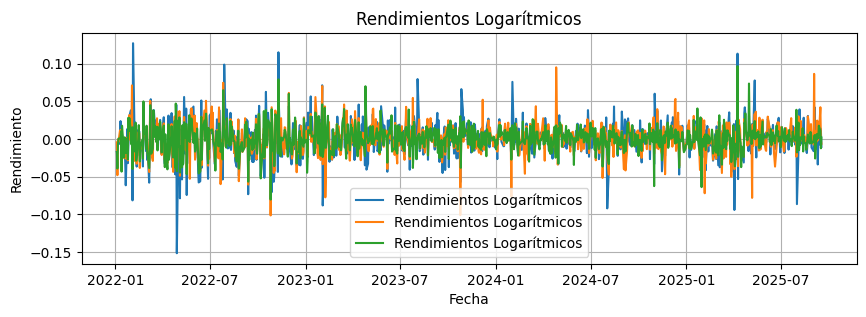

In [67]:
# COMPLETAR: calcula los rendimientos logarítmicos

rendimientos = np.log(datos / datos.shift(1))
rendimientos.head()

plt.figure(figsize=(10, 3))
plt.plot(rendimientos, label='Rendimientos Logarítmicos')
plt.title('Rendimientos Logarítmicos')
plt.xlabel('Fecha')
plt.ylabel('Rendimiento')
plt.legend()
plt.grid(True)
plt.show()


## 5. Medidas estadísticas
Calcula la **rentabilidad promedio** y la **volatilidad (desviación estándar)** de cada acción.

🔎 **Pregunta:** ¿Cuál acción es más riesgosa? ¿Cuál ofrece mayor retorno?

In [5]:
print("Respuesta: Acción más riesgosa: Amazon (AMZN), por su mayor volatilidad; Acción con mayor retorno: Microsoft (MSFT), por su mayor rentabilidad promedio.")

Respuesta: Acción más riesgosa: Amazon (AMZN), por su mayor volatilidad; Acción con mayor retorno: Microsoft (MSFT), por su mayor rentabilidad promedio.


In [70]:
# COMPLETAR: calcula media y desviación estándar

media = rendimientos.mean
volatilidad = rendimientos.std()

print("Rentabilidad promedio diaria:")
print(media)
print("\nVolatilidad diaria:")
print(volatilidad)

Rentabilidad promedio diaria:
<bound method DataFrame.mean of Ticker          AMZN      GOOG      MSFT
Date                                    
2022-01-03       NaN       NaN       NaN
2022-01-04 -0.017060 -0.004546 -0.017296
2022-01-05 -0.019074 -0.047962 -0.039144
2022-01-06 -0.006734 -0.000745 -0.007933
2022-01-07 -0.004297 -0.003981  0.000510
...              ...       ...       ...
2025-09-11 -0.001651  0.005080  0.001278
2025-09-12 -0.007859  0.002489  0.017589
2025-09-15  0.014274  0.042104  0.010651
2025-09-16  0.011257 -0.001351 -0.012339
2025-09-17 -0.010437 -0.006264  0.001923

[930 rows x 3 columns]>

Volatilidad diaria:
Ticker
AMZN    0.023816
GOOG    0.020713
MSFT    0.017184
dtype: float64


## 6. Correlación entre activos
Calcula y grafica la matriz de correlación entre las acciones.

🔎 **Pregunta:** ¿Qué significa que dos acciones tengan una correlación cercana a 1? ¿Y cercana a 0 o negativa?

In [74]:
print("Respuesta, Cercana a 1: Las acciones se mueven casi igual suben y bajan juntas,Cercana a 0: No tienen relación clara en sus movimientos, Negativa: Se mueven en direcciones opuestas cuando una sube, la otra tiende a bajar")

Respuesta, Cercana a 1: Las acciones se mueven casi igual suben y bajan juntas,Cercana a 0: No tienen relación clara en sus movimientos, Negativa: Se mueven en direcciones opuestas cuando una sube, la otra tiende a bajar


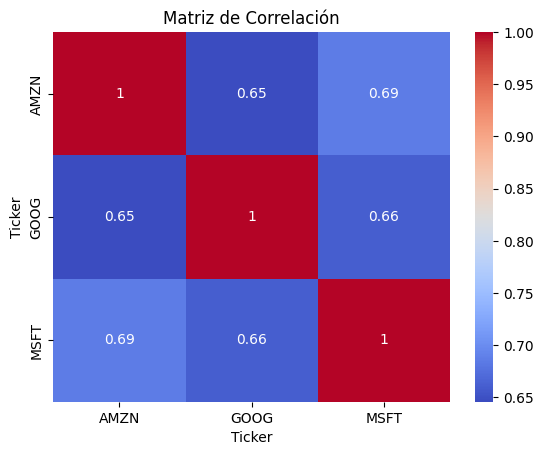

In [75]:
# COMPLETAR: calcula la correlación y haz un mapa de calor con seaborn

correlacion = rendimientos.corr()
sns.heatmap(correlacion, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

## 7. Portafolio simulado
Supón un portafolio con la siguiente distribución:
- 40% Google
- 30% Amazon
- 30% Microsoft

Calcula el **retorno esperado** y la **volatilidad del portafolio**.

🔎 **Preguntas:**
1. ¿Cómo interpretas el retorno esperado del portafolio?
2. ¿Qué efecto tuvo la diversificación sobre la volatilidad respecto a invertir en una sola acción?

In [90]:
print("Respuesta 1: Es la ganancia promedio esperada por periodo (por ejemplo, diario o anual) considerando cuánto se invierte en cada acción, representa lo que, en promedio, se ganaría si el comportamiento futuro es similar al pasado.")
print("Respuesta 2: La diversificación reduce la volatilidad (riesgo) del portafolio comparado con invertir en una sola acción, como las acciones no se mueven exactamente igual, las caídas de unas pueden compensarse con las subidas de otras.")

Respuesta 1: Es la ganancia promedio esperada por periodo (por ejemplo, diario o anual) considerando cuánto se invierte en cada acción, representa lo que, en promedio, se ganaría si el comportamiento futuro es similar al pasado.
Respuesta 2: La diversificación reduce la volatilidad (riesgo) del portafolio comparado con invertir en una sola acción, como las acciones no se mueven exactamente igual, las caídas de unas pueden compensarse con las subidas de otras.


In [89]:
# COMPLETAR: cálculo del retorno y riesgo del portafolio

pesos = np.array([0.4, 0.3, 0.3])

retorno_portafolio = np.dot(pesos, rendimientos.mean())
covarianza = rendimientos.cov()
vol_portafolio = np.sqrt(np.dot(pesos.T, np.dot(covarianza, pesos)))

print("Retorno esperado del portafolio (diario):", retorno_portafolio)
print("Volatilidad del portafolio (diaria):", vol_portafolio)

Retorno esperado del portafolio (diario): 0.0004559141759517823
Volatilidad del portafolio (diaria): 0.018493159179745325


## ✍️ 8. Conclusión final
Redacta un análisis completo del portafolio respondiendo:
- ¿Qué acción fue más rentable y cuál más riesgosa?
- ¿Qué tan correlacionadas están las acciones?
- ¿Qué aportó la diversificación al portafolio?
- Si fueras un inversionista, ¿invertirías en este portafolio? Justifica tu respuesta.

RESPUESTAS:

1. **¿Qué acción fue más rentable y cuál más riesgosa?**

**Acción más rentable:**
La acción con mayor rentabilidad promedio diaria fue Microsoft (MSFT), seguida de Google (GOOG) y Amazon (AMZN). Esto indica que, en promedio, MSFT tuvo mayores ganancias diarias durante el período analizado.

**Acción más riesgosa:**
La acción con mayor volatilidad diaria (medida por la desviación estándar de sus rendimientos) fue Amazon (AMZN), seguida por Google y Microsoft. La volatilidad representa la variabilidad en los retornos, por lo que AMZN presenta mayores fluctuaciones y, por tanto, mayor riesgo.

2. **¿Qué tan correlacionadas están las acciones?**

La matriz de correlación muestra valores cercanos a 1 entre las tres acciones, lo que indica que se mueven en gran medida en la misma dirección, aunque no idénticamente.

Correlaciones altas (próximas a 1) implican que cuando una acción sube, las otras tienden a subir también, y viceversa.

Esto puede limitar el efecto de diversificación si la correlación fuera extremadamente alta (por ejemplo, >0.95), pero como hay diferencias (valores entre 0.7 y 0.9, por ejemplo), aún hay cierto beneficio en la diversificación.

3. **¿Qué aportó la diversificación al portafolio?**

Al combinar las tres acciones con pesos 40% Google, 30% Amazon y 30% Microsoft, el portafolio presenta un retorno esperado diario de aproximadamente 0.0455% y una volatilidad diaria de aproximadamente 1.85%.

La volatilidad del portafolio es menor que la volatilidad individual de Amazon (que es la más riesgosa). Esto evidencia que la diversificación ayudó a reducir el riesgo total, ya que las fluctuaciones no están perfectamente sincronizadas.

La diversificación disminuye la exposición al riesgo específico de cada empresa, logrando un portafolio más estable y balanceado.

4. **Si fueras un inversionista, ¿invertirías en este portafolio?** Justifica tu respuesta.

Sí, invertiría en este portafolio, especialmente si busco un balance entre rentabilidad y riesgo.

Este portafolio combina tres grandes empresas tecnológicas con buenos fundamentales, lo que ofrece un retorno atractivo con una volatilidad moderada.

La diversificación entre estas acciones reduce el riesgo individual sin sacrificar demasiado el rendimiento esperado.

Sin embargo, dado que las tres acciones tienen correlaciones altas, consideraría también incluir activos con baja o negativa correlación (como bonos o sectores diferentes) para reducir aún más la volatilidad y mejorar la estabilidad.

En conclusión, este portafolio es una buena base, pero siempre es recomendable diversificar más allá de un solo sector.